In [1]:
# library packages 
import os
import glob
import matplotlib
import numpy as np
import pandas as pd
from skimage import io
from pathlib import Path
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from scipy.signal import argrelextrema
from skimage.io import imread, imshow, imsave
from skimage.transform import rescale, resize,downscale_local_mean
from embryo_analyses_library import KyMeas, find_maxima, filterMaxima, findChromosomeMaxima, plotMaxima, reformatPositionsPoles, reformatPositionsChromosome
from embryo_analyses_library import plotDistances, savecsvfile, kymoDistance, guessThreshold, ChromosomeMaximaQuality

In [2]:
# input folder
path = r"D:\data\Analysis Data\python_analysis\input"

# output for pole-to-pole
output_csv = r"D:\data\Analysis Data\python_analysis\process_kymo\output_csv"
output_plot = r"D:\data\Analysis Data\python_analysis\process_kymo\output_plots"

# output for chromosome-to-chromosome
output_csv_chromosome = r"D:\data\Analysis Data\python_analysis\process_kymo\output_csv_chromosome"
output_plot_chromosome = r"D:\data\Analysis Data\python_analysis\process_kymo\output_plot_chromosome"

# out for rescaled kymograph
output_rescaled_kymo = r"D:\data\Analysis Data\python_analysis\process_kymo\output_rescaled_kymo"

In [3]:
image_file_list = KyMeas(path,'tif')

(2, 31, 530)
Average_threshold: 4995.0
Image 4cell_ABa_kymo.tif can be nicely processed with threshold: 4995.0
4cell_ABa_kymo.tif : filtered
Pole maxima positions
    pole_1  pole_2
0     233     303
1     230     301
2     229     302
3     228     301
4     228     303


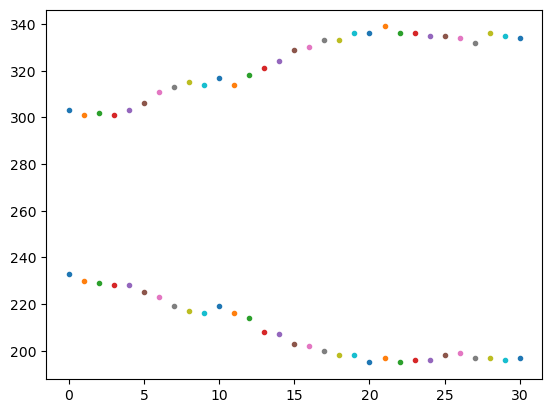

Chromosome maxima positions
     chromosome_1  chromosome_2
0            264           264
1            264           264
2            265           265
3            266           266
4            266           266
5            266           266
6            265           265
7            266           266
8            265           265
9            258           274
10           249           279
11           247           285
12           244           289
13           243           291
14           242           293
15           240           293
16           237           295
17           236           295
18           237           298
19           235           297
20           236           297
21           265           296


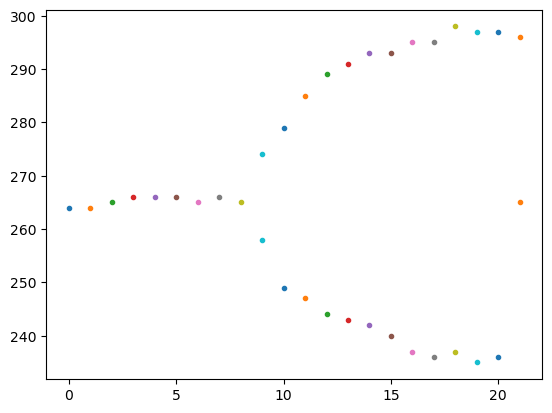

Quality:  1.0
Centromsome distance


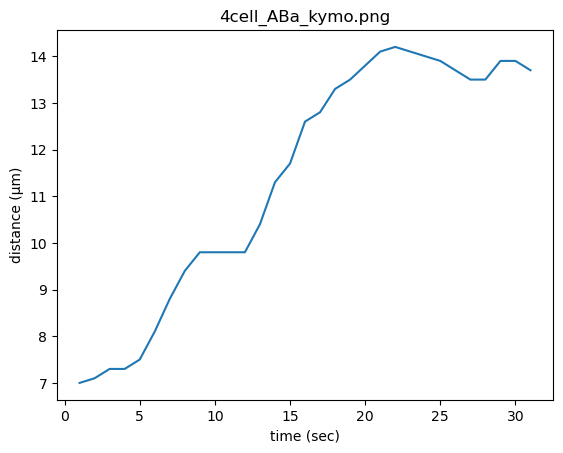

Chromosome distance


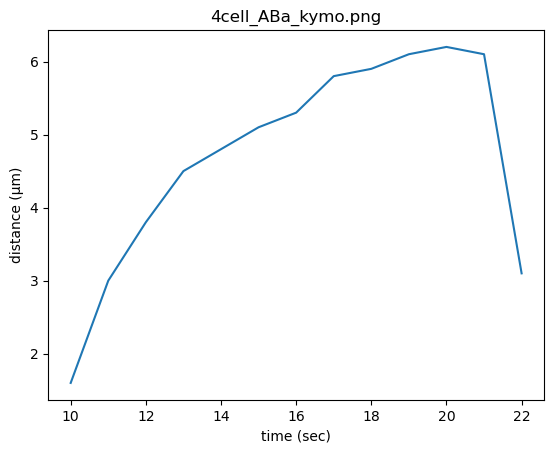

(2, 31, 550)
Average_threshold: 4995.0
Image 4cell_ABp_kymo.tif can be nicely processed with threshold: 4995.0
4cell_ABp_kymo.tif : filtered
Pole maxima positions
    pole_1  pole_2
0     235     310
1     238     310
2     237     309
3     235     312
4     230     313


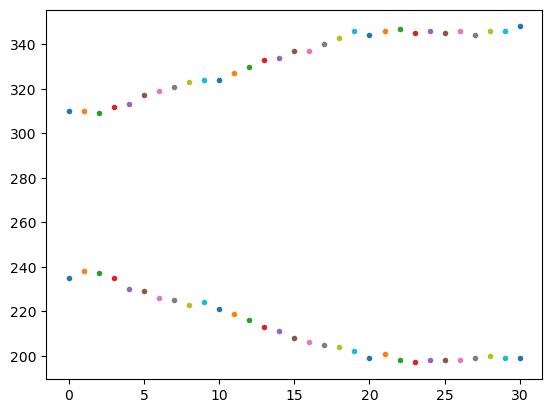

Chromosome maxima positions
     chromosome_1  chromosome_2
0            275           275
1            273           273
2            273           273
3            272           272
4            273           273
5            275           275
6            275           275
7            273           273
8            266           282
9            258           287
10           254           294
11           250           294
12           248           297
13           246           298
14           246           299
15           246           302
16           243           305
17           240           302
18           243           306
19           240           304
20           238           305
21           240           305


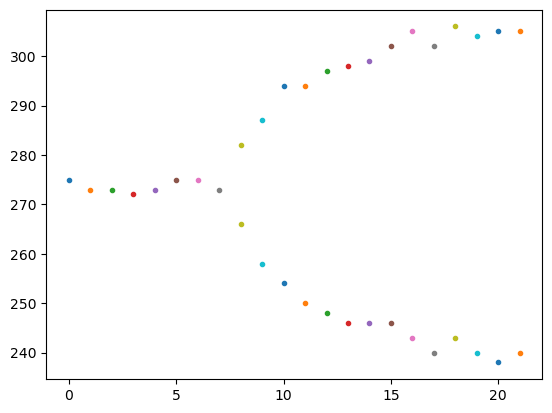

Quality:  1.0
Centromsome distance


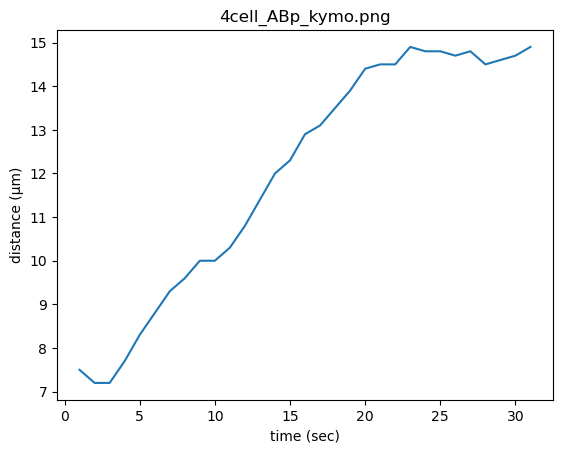

Chromosome distance


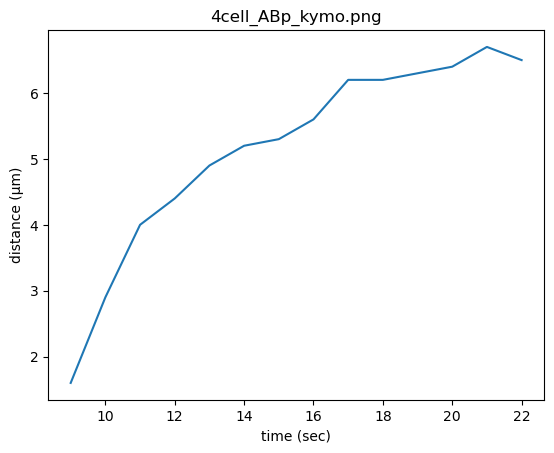

(2, 31, 470)
Average_threshold: 2545.0
Image 4cell_EMS_kymo.tif can be nicely processed with threshold: 2545.0
4cell_EMS_kymo.tif : filtered
Pole maxima positions
    pole_1  pole_2
0     195     271
1     198     269
2     197     265
3     198     267
4     199     267


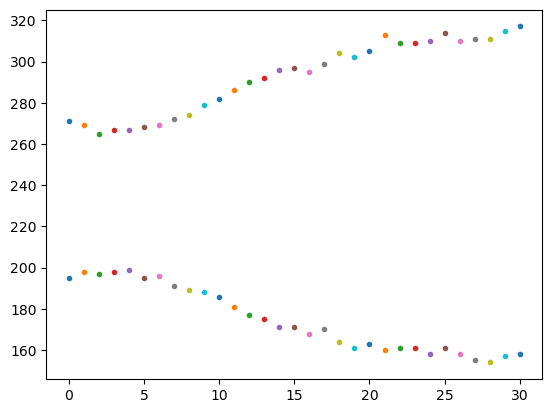

Chromosome maxima positions
     chromosome_1  chromosome_2
0            233           233
1            234           234
2            234           234
3            235           235
4            233           233
5            234           234
6            232           232
7            233           233
8            224           240
9            219           247
10           214           255
11           213           256
12           211           257
13           208           258
14           208           261
15           206           257
16           205           256
17           207           263
18           210           262
19           230           265
20           228           228
21           232           232


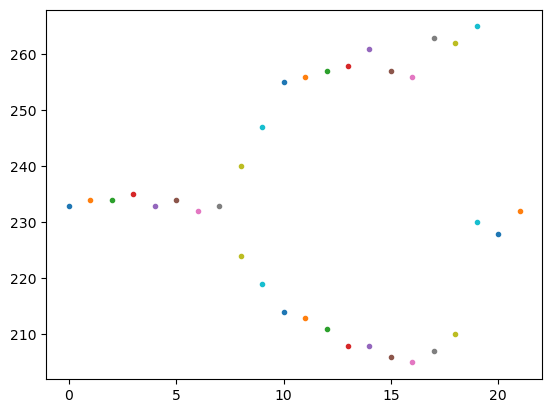

Quality:  1.0
Centromsome distance


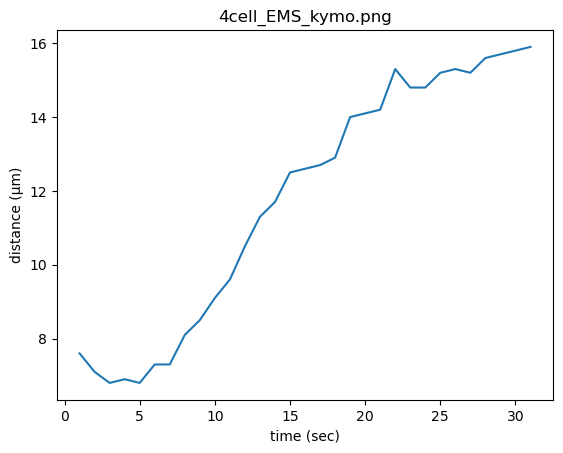

Chromosome distance


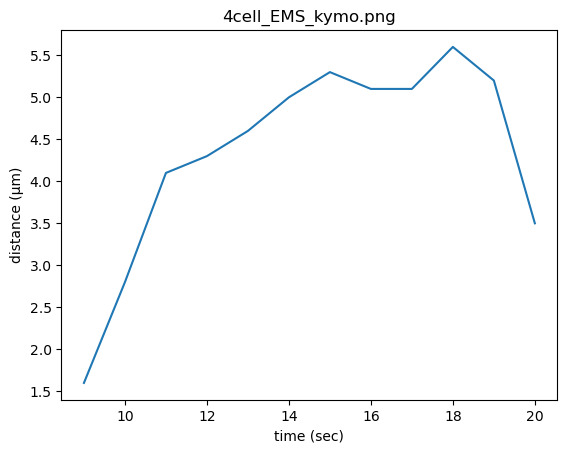

(2, 31, 460)
Average_threshold: 2145.0
Image 4cell_P2_kymo.tif can be nicely processed with threshold: 2145.0
4cell_P2_kymo.tif : filtered
Pole maxima positions
    pole_1  pole_2
0     196     263
1     198     264
2     198     266
3     199     265
4     197     265


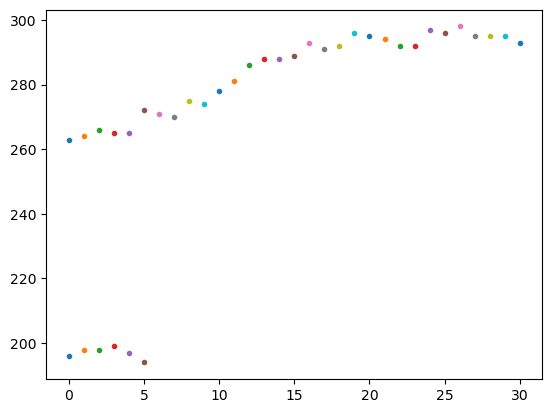

Error: maxima were incorrectly detected D:/data/Analysis Data/python_analysis/input/4cell_P2_kymo.tif
High quality detection:  3
Low quality detection:  0
Number of errors:  1


In [4]:
# call and execute the analyses functions from the library        
def analyzeFile(filename, folder):
    """
    rescale the kymograph for visualization, save and apply the other function on each file while saving the outputs
    in different  sub-folders
    """
    # read the image file, crop out the unwanted frame (optional), rescale the image and save
    input_image = imread(filename)
    input_image_cropped = input_image[:, 3:25, :]
    print(input_image.shape)
    input_image_rescale = rescale(input_image, [1, 10, 1], anti_aliasing = False) 
    input_img_rescale_join = os.path.join(folder, filename.split("/")[-1]).replace("\\", "/")
    imsave(input_img_rescale_join, input_image_rescale[1])
    
    # calculate the average threshold using the guessThreshold function and introduce error message when it fails
    try: 
        threshold = guessThreshold(input_image)
        filename = filename.split("/")[-1]
        print("Image", filename, "can be nicely processed with threshold:", threshold)

    # continue analyzing other files if one file cannot be analyse.
    except ZeroDivisionError:
        print("Image", filename, "cannot be analysed")
        return 
    
    # apply the functions for different operations for both the centrosome and chromosome detection
    
    """FOR CENTROSOME (POLES)"""
    maxima_x = find_maxima(input_image, threshold, channel = 1) 
    #plotMaxima(maxima_x) # show the maxima for each timepoint before filtering
    maxima = filterMaxima(maxima_x, 50)
    print(filename, ": filtered")
   
    centromosomes_table = reformatPositionsPoles(maxima) # read out the position of the maxima for centrosome
    print("Pole maxima positions\n", centromosomes_table)
    
    plotMaxima(maxima) # plotting the centrosome after filtering out the unwanted maxima
    
    """FOR CHROMOSOME"""
    #find the maxima for the chromosome channel and output the intensity in plot
    maxima_chromosome = find_maxima(input_image_cropped, threshold, channel = 0)
    #plotMaxima(maxima_chromosome)
    
    MaxFindChromosome = findChromosomeMaxima(maxima, maxima_chromosome)
    #plotMaxima(MaxFindChromosome)
    filterChromosomeMaxima = filterMaxima(MaxFindChromosome, 50)
    
    chromosome_table = reformatPositionsChromosome(filterChromosomeMaxima) # read out the positions of the maxima for chromosome
    print("Chromosome maxima positions\n", chromosome_table)

    plotMaxima(filterChromosomeMaxima)  
    #print(filterChromosomeMaxima)
        
    # calculate and display the quality of the chromosome maxima detected on a scale of 0 and 1 (1 been the best)
    quality = ChromosomeMaximaQuality(filterChromosomeMaxima)
    print("Quality: ", quality)
    
    
    """FOR CENTROSOME (POLES)"""
    
    print("Centromsome distance")
    
    # calculate the distance between the detected maximum
    frames, distances = kymoDistance(maxima) 
    
    #plot the distance and save in a given format
    plotfilename = filename.split("/")[-1] 
    plotfilename = plotfilename.split(".")[0] + ".png"  
    plotDistances(plotfilename, output_plot, frames, distances) # 
    
    # save the distance values in csv files
    csvfilename = filename + ".csv"
    savecsvfile(csvfilename, output_csv, frames, distances)
    
    
    """FOR CHROMOSOME"""
    
    print("Chromosome distance")
    
    # calculate the distance between the detected maximum
    frames_chromosome, distances_chromosome = kymoDistance(filterChromosomeMaxima)
    
    #plot the distance and save in a given format
    plotDistances(plotfilename, output_plot_chromosome, frames_chromosome, distances_chromosome)
    
    # save the distance values in csv files
    csvfilename = filename + ".csv"
    savecsvfile(csvfilename, output_csv_chromosome, frames_chromosome, distances_chromosome)
    
    return quality
    
# initialize the count of the data analyzed using low and high quality variables
count_high_quality_dataset = 0
count_low_quality_dataset = 0
count_errors = 0

# read through the file in the defined folder and apply the analysis functions
for file in image_file_list:
    try:
        quality_analyses = analyzeFile(file, output_rescaled_kymo)
        if quality_analyses >= 0.9:
            count_high_quality_dataset = count_high_quality_dataset+1
        else:
            count_low_quality_dataset = count_low_quality_dataset+1
    except:
        print('Error: maxima were incorrectly detected', file)
        
        count_errors = count_errors+1
        
    #break
        
print("High quality detection: ", count_high_quality_dataset)
print("Low quality detection: ", count_low_quality_dataset)
print("Number of errors: ", count_errors)
    